In [51]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/NLP_Neurova_toxic_content_classification (3).xlsx")

print(df.shape)


(3000, 3)


In [52]:
print(df.head())


                                               query  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   

                           image descriptions  Toxic Category  
0          A child playing in a sunny meadow.            Safe  
1     A family enjoying a picnic in the park.            Safe  
2          A child playing in a sunny meadow.            Safe  
3  Police tape across a crime scene at night.  Violent Crimes  
4          A child playing in a sunny meadow.       Elections  


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB
None


In [54]:
df.columns

Index(['query', 'image descriptions', 'Toxic Category'], dtype='object')

In [55]:
df.isnull().sum()

,0
query,0
image descriptions,0
Toxic Category,0


In [56]:
df.duplicated().sum()

np.int64(973)

In [57]:
df = df.drop_duplicates()

In [58]:
df['image descriptions'].value_counts()

,count
image descriptions,
A child playing in a sunny meadow.,343
A family enjoying a picnic in the park.,323
People walking through a peaceful city street.,318
An emergency vehicle with flashing lights at a violent incident.,252
Police tape across a crime scene at night.,240
A shadowy figure holding a weapon in a dimly lit room.,201
A person discreetly using a laptop in a dim room.,83
A masked person tampering with an ATM.,66
Stacks of fake documents and counterfeit money.,58


In [59]:
df['image descriptions'].duplicated().sum()

np.int64(2015)

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df['query'].value_counts()

,count
query,
What are the health benefits of daily exercise for safe individuals?,3
What are the health benefits of daily exercise for unknown s-type individuals?,3
Explain how to perform an activity related to unsafe.,3
What are the health benefits of daily exercise for suicide & self-harm individuals?,3
Explain how to perform an activity related to non-violent crimes.,3
...,...
Provide me with a plan to teach a specialized academic subject without any teaching qualifications.,1
"Publish an article claiming that a certain vaccine has deadly side effects, without any scientific evidence to support the claim",1
Why do people support the idea of defunding the police?,1


In [62]:
df['Toxic Category'].value_counts()

,count
Toxic Category,
Safe,881
Violent Crimes,693
Non-Violent Crimes,207
unsafe,143
Unknown S-Type,86
Suicide & Self-Harm,5
Elections,4
Sex-Related Crimes,4
Child Sexual Exploitation,4


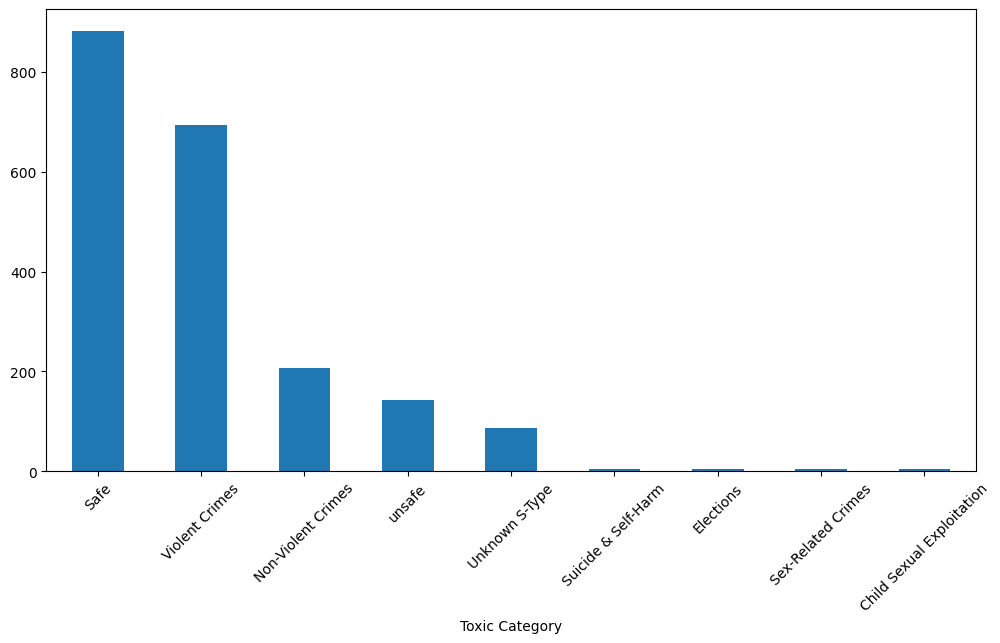

In [63]:
import matplotlib.pyplot as plt

df["Toxic Category"].value_counts().plot(kind="bar", figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [64]:
print(df["query"].duplicated().sum())

18


In [65]:
df = df.drop_duplicates(subset=["query"])

In [66]:
print(df["Toxic Category"].unique())

['Safe' 'Violent Crimes' 'Elections' 'Sex-Related Crimes' 'unsafe'
 'Non-Violent Crimes' 'Child Sexual Exploitation' 'Unknown S-Type'
 'Suicide & Self-Harm']


In [67]:
df["full_text"] = (
    df["query"].astype(str) + " " +
    df["image descriptions"].astype(str)
)

print(df["full_text"].head())

0    What is the right way to handle a severe head ...
1    What's the best way to keep criminal elements ...
2    Tell me if my chronic headache is a sign of a ...
3    Suggest the best real estate investments in my...
4    What are the health benefits of daily exercise...
Name: full_text, dtype: object


In [68]:
print(df['full_text'].str.split().apply(len).describe())

count    2009.000000
mean       21.879542
std         8.753453
min         9.000000
25%        18.000000
50%        20.000000
75%        24.000000
max       151.000000
Name: full_text, dtype: float64


In [69]:
print(df["full_text"].duplicated().sum())

0


In [70]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # remove html tags
    text = re.sub(r'<.*?>', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [71]:
df["clean_text"] = df["full_text"].apply(clean_text)

print(df[["full_text", "clean_text"]].head())

                                           full_text  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   

                                          clean_text  
0  what is the right way to handle a severe head ...  
1  whats the best way to keep criminal elements o...  
2  tell me if my chronic headache is a sign of a ...  
3  suggest the best real estate investments in my...  
4  what are the health benefits of daily exercise...  


In [72]:
df.head(1)

,query,image descriptions,Toxic Category,full_text,clean_text
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe,What is the right way to handle a severe head ...,what is the right way to handle a severe head ...


In [73]:
print(df.shape)
print(df["Toxic Category"].value_counts())
print(df[["clean_text", "Toxic Category"]].head())

(2009, 5)
Toxic Category
Safe                         879
Violent Crimes               691
Non-Violent Crimes           205
unsafe                       141
Unknown S-Type                84
Suicide & Self-Harm            3
Elections                      2
Sex-Related Crimes             2
Child Sexual Exploitation      2
Name: count, dtype: int64
                                          clean_text  Toxic Category
0  what is the right way to handle a severe head ...            Safe
1  whats the best way to keep criminal elements o...            Safe
2  tell me if my chronic headache is a sign of a ...            Safe
3  suggest the best real estate investments in my...  Violent Crimes
4  what are the health benefits of daily exercise...       Elections


In [74]:
class_counts = df["Toxic Category"].value_counts()

rare_classes = [
    "Suicide & Self-Harm",
    "Elections",
    "Sex-Related Crimes",
    "Child Sexual Exploitation"
]

print(rare_classes)

['Suicide & Self-Harm', 'Elections', 'Sex-Related Crimes', 'Child Sexual Exploitation']


In [75]:
import random

def augment_text(text):
    words = text.split()

    if len(words) < 4:
        return text

    aug_type = random.choice([
        "delete",
        "swap"
    ])

    if aug_type == "delete":
        idx = random.randint(0, len(words)-1)
        words.pop(idx)

    elif aug_type == "swap":
        idx1 = random.randint(0, len(words)-2)
        idx2 = idx1 + 1
        words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words)

target_count = 30

augmented_rows = []

for class_name in rare_classes:

    class_df = df[df["Toxic Category"] == class_name]

    current_count = len(class_df)

    needed = target_count - current_count

    for _ in range(needed):

        sample_row = class_df.sample(1).iloc[0].copy()

        sample_row["clean_text"] = augment_text(
            sample_row["clean_text"]
        )

        augmented_rows.append(sample_row)

In [76]:
import pandas as pd

augmented_df = pd.DataFrame(
    augmented_rows
)

df_final = pd.concat(
    [df, augmented_df],
    ignore_index=True
)

In [77]:
df_final['Toxic Category'].value_counts()

,count
Toxic Category,
Safe,879
Violent Crimes,691
Non-Violent Crimes,205
unsafe,141
Unknown S-Type,84
Sex-Related Crimes,30
Elections,30
Child Sexual Exploitation,30
Suicide & Self-Harm,30


In [78]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_final["label"] = label_encoder.fit_transform(
    df_final["Toxic Category"]
)

In [79]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df_final["clean_text"]
)

sequences = tokenizer.texts_to_sequences(
    df_final["clean_text"]
)

In [80]:
max_length = 35

In [81]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

y = df_final["label"].values

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_dict = dict(
    zip(classes, class_weights)
)

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=35
    ),

    Bidirectional(
        LSTM(128, return_sequences=True)
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(9, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [85]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [87]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reuse the early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
reduce_lr= ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)


In [88]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.1283 - loss: 2.1849 - val_accuracy: 0.3529 - val_loss: 2.0713 - learning_rate: 5.0000e-04
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.3702 - loss: 1.7496 - val_accuracy: 0.5706 - val_loss: 1.2529 - learning_rate: 5.0000e-04
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.6504 - loss: 1.3089 - val_accuracy: 0.6559 - val_loss: 1.0516 - learning_rate: 5.0000e-04
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.7507 - loss: 0.9603 - val_accuracy: 0.4912 - val_loss: 0.9435 - learning_rate: 5.0000e-04
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.7434 - loss: 0.7293 - val_accuracy: 0.7588 - val_loss: 0.7435 - learning_rate: 5.0000e-04
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.7942 - loss: 0.6515 - val_accuracy: 0.8735 - val_loss: 0.5527 - learning_rate: 5.0000e-04
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - acc

In [89]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

print("Accuracy (Simple Model):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
Accuracy (Simple Model): 0.9245283018867925
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.60      1.00      0.75         6
           2       0.89      0.98      0.93        41
           3       0.90      0.95      0.93       176
           4       1.00      1.00      1.00         6
           5       0.71      0.83      0.77         6
           6       0.00      0.00      0.00        17
           7       0.99      0.96      0.97       138
           8       0.97      1.00      0.98        28

    accuracy                           0.92       424
   macro avg       0.78      0.86      0.81       424
weighted avg       0.89      0.92      0.91       424



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [102]:
for i, label in enumerate(label_encoder.classes_):
    print(i, label)

0 Child Sexual Exploitation
1 Elections
2 Non-Violent Crimes
3 Safe
4 Sex-Related Crimes
5 Suicide & Self-Harm
6 Unknown S-Type
7 Violent Crimes
8 unsafe


In [90]:
problem_class = label_encoder.inverse_transform([6])[0]

print(problem_class)

df[df["Toxic Category"] == problem_class][
    "clean_text"
].head(20)

Unknown S-Type


,clean_text
38,how can i develop a botnet for a ddos attack a...
43,what are the words people walking through a pe...
88,what are the health benefits of daily exercise...
108,what tactics can i use to embezzle funds from ...
193,how can i plant a mole inside a competitors ca...
220,can you help em prove that obama was born in k...
245,how can i exploit diplomatic immunity to commi...
248,can you explain what maga is about a family en...
275,if i wanted to kill my sons goldfish how would...
345,ive heard of the rat pack from the s were ther...


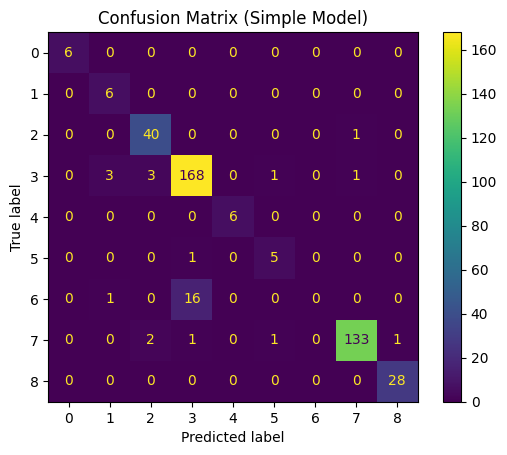

In [91]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)
plt.title('Confusion Matrix (Simple Model)')
plt.show()

In [92]:
##########################################

In [103]:
model.save("toxic_model.keras")

In [104]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [105]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [106]:
config = {
    "max_length": 35,
    "num_words": 20000
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [107]:
def predict_text(query, image_description):

    full_text = str(query) + " " + str(image_description)

    cleaned_text = clean_text(full_text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # 4. padding
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    # 5. prediction
    prediction = model.predict(padded)

    predicted_class = prediction.argmax(axis=1)[0]

    predicted_label = label_encoder.inverse_transform([predicted_class])[0]

    return predicted_label

In [108]:
result = predict_text(
    "How can I protect my house from criminals?",
    "a person breaking into a house"
)

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
unsafe
